In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import segmentation_models_pytorch as smp

c:\Users\hunnu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
lol1_train_low=r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv1\train\low"
lol1_train_high=r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv1\train\high"
lol1_test_low=r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv1\test\low"
lol1_test_high=r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv1\test\high"
lol2_train_low=r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv2-real\train\low"
lol2_train_high=r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv2-real\train\high"
lol2_test_low=r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv2-real\test\low"
lol2_test_high=r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv2-real\test\high"

In [4]:
import os

In [5]:
lol2_train_low_images = sorted(os.listdir(lol2_train_low))
lol2_train_high_images = sorted(os.listdir(lol2_train_high))
lol2_test_low_images = sorted(os.listdir(lol2_test_low))
lol2_test_high_images = sorted(os.listdir(lol2_test_high))

In [6]:
lol1_train_low_images = sorted(os.listdir(lol1_train_low))
lol1_train_high_images = sorted(os.listdir(lol1_train_high))

lol1_test_low_images = sorted(os.listdir(lol1_test_low))
lol1_test_high_images = sorted(os.listdir(lol1_test_high))

In [7]:
class LowLightDataset(Dataset):

    def __init__(self, low_dirs, high_dirs, transform=None):
        self.transform = transform
        self.image_pairs = []

        for low_dir, high_dir in zip(low_dirs, high_dirs):

            low_images = sorted(os.listdir(low_dir))
            high_images = sorted(os.listdir(high_dir))

            for low_img, high_img in zip(low_images, high_images):
                self.image_pairs.append((
                    os.path.join(low_dir, low_img),
                    os.path.join(high_dir, high_img)
                ))

    def __len__(self):
        return len(self.image_pairs)

    def __getitem__(self, idx):

        low_path, high_path = self.image_pairs[idx]

        low_img = Image.open(low_path).convert("RGB")
        high_img = Image.open(high_path).convert("RGB")

        if self.transform:
            low_img = self.transform(low_img)
            high_img = self.transform(high_img)

        return low_img, high_img

In [8]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [9]:
train_dataset = LowLightDataset(
    low_dirs=[lol1_train_low,lol2_train_low],
    high_dirs=[lol1_train_high,lol2_train_high],
    transform=transform)

test_dataset = LowLightDataset(
    low_dirs=[lol1_test_low,lol2_test_low],
    high_dirs=[lol1_test_high,lol2_test_high],
    transform=transform)

In [10]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [12]:
from pytorch_msssim import ssim
import torchvision.models as tv_models

#VGG perceptual loss
_vgg = tv_models.vgg16(weights='IMAGENET1K_V1').features[:16].eval().to(device)
for p in _vgg.parameters():
    p.requires_grad = False

_vgg_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
_vgg_std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)


def vgg_loss_fn(pred, target):
    pred_n = (pred - _vgg_mean) / _vgg_std
    target_n = (target - _vgg_mean) / _vgg_std
    return nn.functional.l1_loss(_vgg(pred_n), _vgg(target_n))


def combined_loss(pred, target, w_l1=1.0, w_ssim=0.3, w_vgg=0.1):

    loss_l1 = nn.functional.l1_loss(pred, target)
    loss_ssim = 1 - ssim(pred, target, data_range=1.0, size_average=True)
    loss_vgg = vgg_loss_fn(pred, target)

    total = w_l1 * loss_l1 + w_ssim * loss_ssim + w_vgg * loss_vgg
    return total, loss_l1.item(), loss_ssim.item(), loss_vgg.item()


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\hunnu/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [02:16<00:00, 4.05MB/s] 


In [13]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3,
    activation=None)

model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-4,weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

In [15]:
epoches= 50
for epoch in range(epoches):
    model.train()
    epoch_loss=0.0

    for low_images, high_images in train_loader:
        low_images, high_images = low_images.to(device), high_images.to(device)
        
        optimizer.zero_grad()
        
        pred = model(low_images)
        pred = torch.clamp(pred, 0, 1)  

        loss, l1_v, ssim_v, vgg_v = combined_loss(pred, high_images, w_l1=1.0, w_ssim=0.3, w_vgg=0.1)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1}: loss={epoch_loss/len(train_loader):.4f} "
          f"(l1={l1_v:.4f}, ssim={ssim_v:.4f}, vgg={vgg_v:.4f})")

Epoch 1: loss=0.6575 (l1=0.1941, ssim=0.4595, vgg=1.3080)
Epoch 2: loss=0.4036 (l1=0.1460, ssim=0.3549, vgg=1.0692)
Epoch 3: loss=0.3427 (l1=0.1567, ssim=0.3668, vgg=1.1120)
Epoch 4: loss=0.3064 (l1=0.1161, ssim=0.2673, vgg=1.0208)
Epoch 5: loss=0.2824 (l1=0.0911, ssim=0.2176, vgg=0.9710)
Epoch 6: loss=0.2699 (l1=0.1070, ssim=0.2379, vgg=0.9301)
Epoch 7: loss=0.2581 (l1=0.0869, ssim=0.2188, vgg=0.9132)
Epoch 8: loss=0.2495 (l1=0.0889, ssim=0.2115, vgg=0.9532)
Epoch 9: loss=0.2422 (l1=0.0875, ssim=0.1848, vgg=0.8825)
Epoch 10: loss=0.2467 (l1=0.0820, ssim=0.2139, vgg=0.9779)
Epoch 11: loss=0.2372 (l1=0.0879, ssim=0.1980, vgg=0.9314)
Epoch 12: loss=0.2396 (l1=0.0753, ssim=0.1786, vgg=0.8983)
Epoch 13: loss=0.2327 (l1=0.0962, ssim=0.2236, vgg=0.9192)
Epoch 14: loss=0.2306 (l1=0.0781, ssim=0.1857, vgg=0.8709)
Epoch 15: loss=0.2207 (l1=0.0853, ssim=0.2152, vgg=0.9190)
Epoch 16: loss=0.2204 (l1=0.0746, ssim=0.1943, vgg=0.9269)
Epoch 17: loss=0.2149 (l1=0.0814, ssim=0.1909, vgg=0.8685)
Epoch 

In [16]:
model.eval()

test_loss = 0.0

with torch.no_grad():
    for low_images, high_images in test_loader:

        low_images = low_images.to(device)
        high_images = high_images.to(device)

        outputs = model(low_images)
        outputs = torch.clamp(outputs, 0, 1)

        loss, l1_v, ssim_v, vgg_v = combined_loss(outputs, high_images, w_l1=1.0, w_ssim=0.3, w_vgg=0.1)
        test_loss += loss.item() * low_images.size(0)

test_loss /= len(test_loader.dataset)
print(f"Test Loss: {test_loss:.4f}")


Test Loss: 0.1564


In [17]:
torch.save(model.state_dict(), "low_light_Unet.pth")

In [21]:
img = Image.open(r"E:\coding\ML\Low_Light_Img_Enhancement\LOLv2-real\test\low\low00789.png").convert("RGB")

img = transform(img)      
img = img.unsqueeze(0)
img = img.to(device)

model.eval()

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [22]:
model.load_state_dict(torch.load("low_light_unet.pth", map_location=device))
model.eval()
with torch.no_grad():
    prediction = model(img)
    prediction = torch.clamp(prediction, 0, 1)

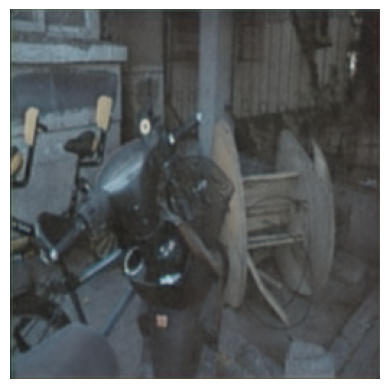

In [23]:
prediction = prediction.squeeze(0)          
prediction = prediction.cpu().permute(1, 2, 0).numpy()

plt.imshow(prediction)
plt.axis("off")
plt.show()